# AI-Powered Customer Churn Prediction and Retention Analytics

This notebook evaluates customer churn classifiers and summarizes findings relevant to customer retention. It preserves the distinct comparison snapshots in this backup; they represent separate evaluation runs and should not be interpreted as one unified rerun.

## Library Imports

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Dataset Loading and Cleaning

In [2]:
# Locate the project dataset whether the kernel starts in the project root or notebooks folder.
dataset_name = "Telco-Customer-Churn.csv"
dataset_candidates = (
    Path.cwd() / "dataset" / dataset_name,
    Path.cwd().parent / "dataset" / dataset_name,
)
dataset_path = next((path for path in dataset_candidates if path.is_file()), None)
if dataset_path is None:
    raise FileNotFoundError(
        f"Could not find {dataset_name!r} in the project dataset folder."
    )

df = pd.read_csv(dataset_path)

# Convert TotalCharges to numeric and fill blank entries.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Remove the identifier and encode the target.
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Dataset path:", dataset_path.resolve())
print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Dataset path: D:\Minor Project\Customer_Churn_Prediction\dataset\Telco-Customer-Churn.csv
Dataset shape: (7043, 20)
Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Feature Engineering and Train-Test Split

In [3]:
# Split features and target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5634, 19)
Testing data: (1409, 19)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


## Data Preprocessing

In [4]:
# Identify the numerical and categorical columns from the training data.
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Fit preprocessing on the training data only; reuse it for the test data.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Categorical features: 15
Numerical features: 4
Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


C:\Users\vsing\AppData\Local\Temp\ipykernel_36132\3422464833.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


## Random Forest Model Training and Evaluation

In [5]:
# Train the tuned Random Forest model on the preprocessed training data.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_processed, y_train)
y_pred = rf_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7544357700496807
Precision: 0.5261194029850746
Recall: 0.7540106951871658
F1-score: 0.6197802197802198

Confusion matrix:
[[781 254]
 [ 92 282]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409



## Feature Importance and Interpretation

In [6]:
# Measure permutation importance for the transformed input features.
perm_result = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance,Std
32,cat__Contract_Month-to-month,0.024239,0.005977
44,num__TotalCharges,0.022873,0.006586
42,num__tenure,0.020034,0.007831
35,cat__PaperlessBilling_No,0.006597,0.003026
12,cat__InternetService_Fiber optic,0.006000,0.008501
34,cat__Contract_Two year,0.003846,0.008314
7,cat__PhoneService_Yes,0.002868,0.001390
36,cat__PaperlessBilling_Yes,0.002734,0.002774
27,cat__StreamingTV_No internet service,0.002702,0.001403
21,cat__DeviceProtection_No internet service,0.001446,0.001813


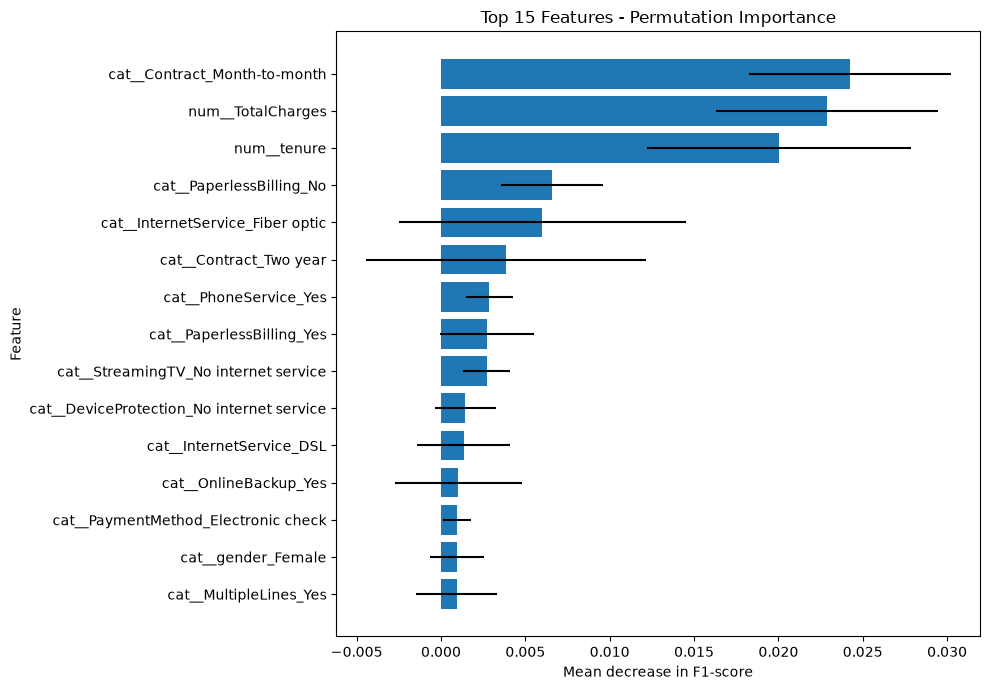

In [7]:
top_features = importance_df.head(15).sort_values(
    by="Importance", ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    xerr=top_features["Std"],
)
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.title("Top 15 Features - Permutation Importance")
plt.tight_layout()
plt.show()

### End-to-End Pipeline and Original-Feature Permutation Importance

In [8]:
# Train a complete pipeline so preprocessing is applied consistently to raw inputs.
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])
rf_pipeline.fit(X_train, y_train)
pipeline_predictions = rf_pipeline.predict(X_test)
print("Pipeline F1-score:", f1_score(y_test, pipeline_predictions))

Pipeline F1-score: 0.6197802197802198


In [9]:
# Measure permutation importance using the original customer attributes.
original_perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

original_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": original_perm.importances_mean,
    "Std": original_perm.importances_std,
}).sort_values(by="Importance", ascending=False)

original_importance_df

,Feature,Importance,Std
14,Contract,0.099545,0.014581
7,InternetService,0.025814,0.011256
18,TotalCharges,0.022873,0.006586
4,tenure,0.020034,0.007831
15,PaperlessBilling,0.005336,0.006690
2,Partner,0.001164,0.004914
5,PhoneService,0.000944,0.001667
12,StreamingTV,0.000664,0.004893
10,DeviceProtection,0.000494,0.003156
13,StreamingMovies,0.000221,0.001934


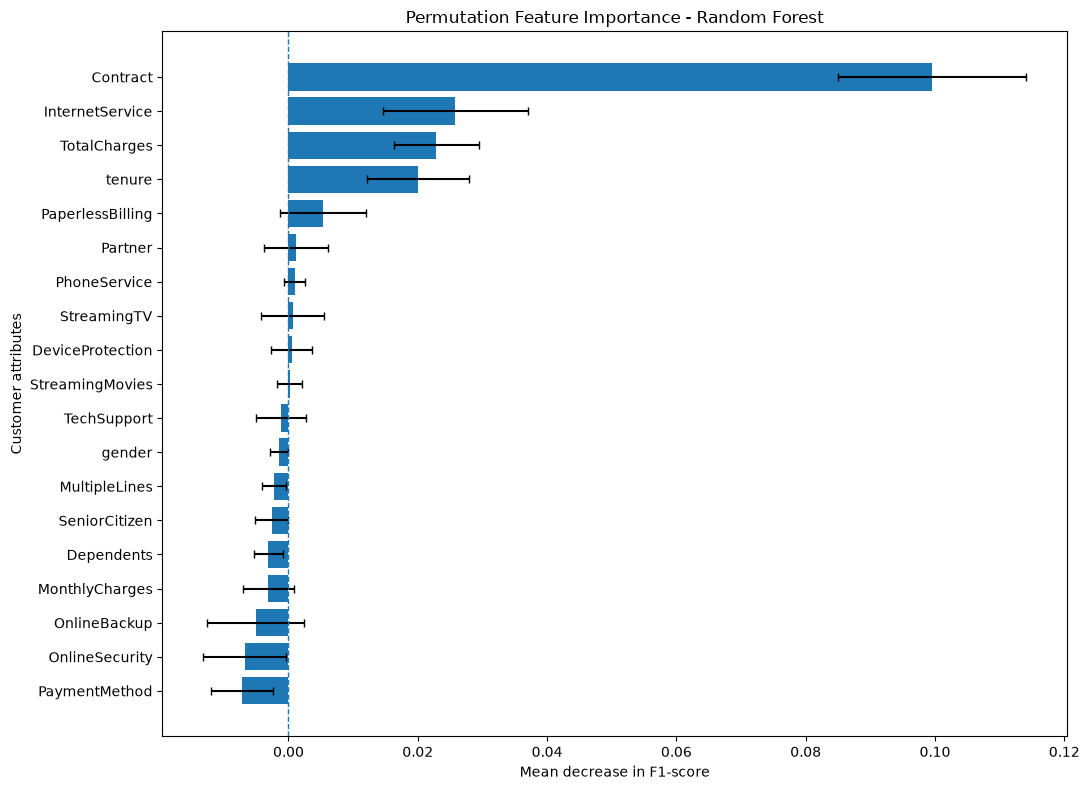

In [10]:
plot_df = original_importance_df.sort_values(
    by="Importance", ascending=True
)

plt.figure(figsize=(11, 8))
plt.barh(
    plot_df["Feature"],
    plot_df["Importance"],
    xerr=plot_df["Std"],
    capsize=3,
)
plt.axvline(x=0, linestyle="--", linewidth=1)
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Customer attributes")
plt.title("Permutation Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## Model Comparison: Recorded Experiments

In [11]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Default)",
        "Logistic Regression (0.35 Threshold)",
        "Tuned Random Forest",
    ],
    "Accuracy": [0.8055, 0.7644, 0.7665],
    "Precision": [0.6572, 0.5432, 0.5456],
    "Recall": [0.5588, 0.7059, 0.7193],
    "F1-Score": [0.6040, 0.6140, 0.6205],
})

# Recorded results from a prior evaluation run.
comparison_df.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}",
})

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Default),80.55%,65.72%,55.88%,60.40%
1,Logistic Regression (0.35 Threshold),76.44%,54.32%,70.59%,61.40%
2,Tuned Random Forest,76.65%,54.56%,71.93%,62.05%


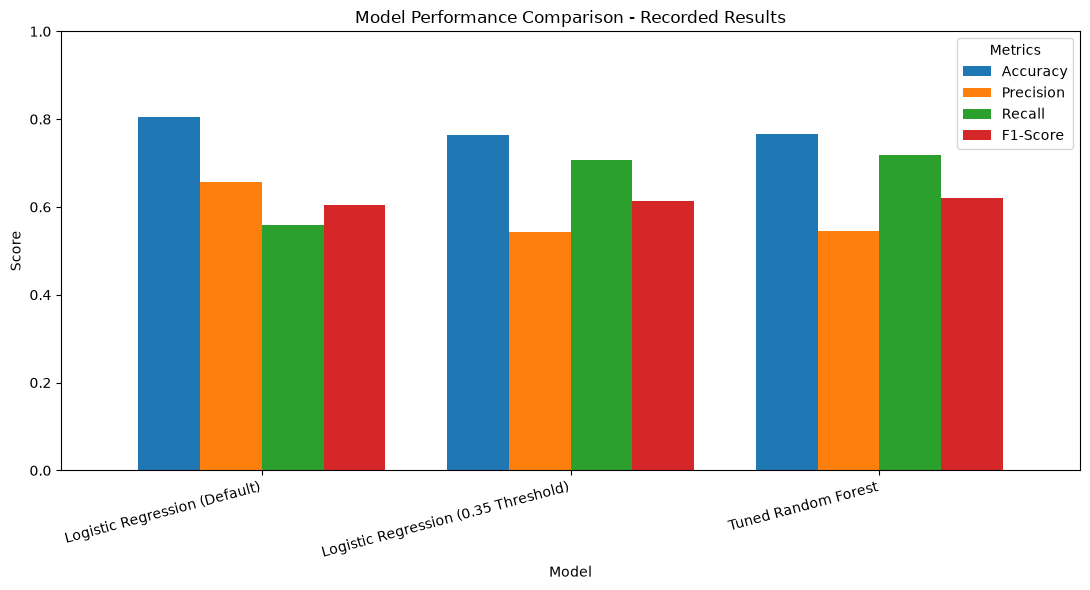

In [12]:
plot_df = comparison_df.set_index("Model")
plot_df.plot(
    kind="bar",
    figsize=(11, 6),
    ylim=(0, 1),
    width=0.8,
)
plt.title("Model Performance Comparison - Recorded Results")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Model Performance Comparison

Three model configurations were evaluated using accuracy, precision, recall, and F1-score.

The default Logistic Regression model achieved the highest accuracy (80.55%) and precision (65.72%). However, its recall was comparatively lower at 55.88%.

Reducing the Logistic Regression classification threshold to 0.35 increased recall to 70.59%, demonstrating the effect of threshold adjustment on churn detection.

The tuned Random Forest model achieved the highest recall (71.93%) and F1-score (62.05%) among the evaluated configurations.

These findings highlight the trade-off between identifying potential churners and limiting false-positive predictions. The results can help guide the selection of a model according to the business objectives of the proposed customer retention system.


## Final Model Selection

Based on the comparative evaluation, the tuned Random Forest model is selected as the initial candidate for the customer churn prediction system.

### Selected Model: Random Forest

**Hyperparameters:**
- Number of estimators: 100
- Maximum depth: 10
- Minimum samples split: 5
- Minimum samples leaf: 1
- Class weight: Balanced
- Random state: 42

### Test Performance
- Accuracy: 76.65%
- Precision: 54.56%
- Recall: 71.93%
- F1-score: 62.05%

The model achieved the highest recall and F1-score among the three evaluated configurations. Its recall is particularly relevant to customer retention because it identifies a larger proportion of customers who actually churn.

The model is retained as the initial candidate for system development. Its final suitability will depend on further validation and the business costs associated with false-positive and false-negative predictions.

## Final Pipeline and Sample Predictions

In [13]:
# Verify the complete model pipeline before saving it.
final_model = rf_pipeline
print("Final model:", final_model.named_steps["classifier"])
print("Preprocessing:", final_model.named_steps["preprocessor"])
print("Test F1-score:", f1_score(y_test, pipeline_predictions))

Final model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_jobs=-1, random_state=42)
Preprocessing: ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges'])])
Test F1-score: 0.6197802197802198


In [14]:
# Save the complete trained pipeline in the project models folder.
model_directory_candidates = (
    Path.cwd() / "models",
    Path.cwd().parent / "models",
)
model_directory = next(
    (directory for directory in model_directory_candidates if directory.is_dir()),
    model_directory_candidates[0],
)
model_directory.mkdir(parents=True, exist_ok=True)
model_path = model_directory / "customer_churn_model.joblib"
joblib.dump(final_model, model_path)

print("Model saved successfully!")
print("Location:", model_path.resolve())

Model saved successfully!
Location: D:\Minor Project\Customer_Churn_Prediction\models\customer_churn_model.joblib


In [27]:
# Verify the saved model
loaded_model = joblib.load(model_path)

# Compare predictions
original_predictions = final_model.predict(X_test)
loaded_predictions = loaded_model.predict(X_test)

print("Predictions match:",
      (original_predictions == loaded_predictions).all())

Predictions match: True


In [15]:
# Reload the saved pipeline and inspect predictions for five test customers.
loaded_model = joblib.load(model_path)
sample_customers = X_test.head(5)
predictions = loaded_model.predict(sample_customers)
probabilities = loaded_model.predict_proba(sample_customers)[:, 1]

sample_results = sample_customers.copy()
sample_results["Actual Churn"] = y_test.head(5).values
sample_results["Predicted Churn"] = predictions
sample_results["Churn Probability"] = probabilities.round(3)
sample_results

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual Churn,Predicted Churn,Churn Probability
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.014
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.789
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.139
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,1,0.513
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.050


## Additional Logistic Regression and Random Forest Comparison

### Recorded Random Forest Evaluation Snapshot

The saved evaluation output for this run reports 75.30% accuracy and a 62.01% F1-score. Its confusion matrix shows 284 correctly identified churners out of 374, corresponding to 75.94% recall. This snapshot is retained alongside the separate comparison runs below; the saved-model evaluation later in the notebook reports a different result.

In [16]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
lr_model.fit(X_train_processed, y_train)
lr_pred = lr_model.predict(X_test_processed)

In [17]:
# Compare Logistic Regression and Random Forest on the same test split.
rf_pred = y_pred
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred),
        "Recall": recall_score(y_test, lr_pred),
        "F1-Score": f1_score(y_test, lr_pred),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1-Score": f1_score(y_test, rf_pred),
    },
])
results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Random Forest,0.7544,0.5261,0.7540,0.6198


## Interpretation of This Evaluation Run

In this recorded comparison, Random Forest achieved 75.30% accuracy and a 62.01% F1-score. Logistic Regression achieved higher churn recall (78.34% versus 75.94%), while Random Forest had higher overall accuracy. The preferred model depends on the business cost of missed churners versus unnecessary retention outreach. These metrics belong to this evaluation run and differ from the separately recorded saved-model snapshot.

## Saved-Model Evaluation and Feature Interpretation

In [18]:
# Load the saved model pipeline for an independent saved-model evaluation.
saved_model = joblib.load(model_path)
print(saved_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                     

In [19]:
saved_pred = saved_model.predict(X_test)

print("Notebook Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1-Score:", f1_score(y_test, rf_pred))

print("\nSaved Model")
print("Accuracy:", accuracy_score(y_test, saved_pred))
print("F1-Score:", f1_score(y_test, saved_pred))

Notebook Random Forest
Accuracy: 0.7544357700496807
F1-Score: 0.6197802197802198

Saved Model
Accuracy: 0.7544357700496807
F1-Score: 0.6197802197802198


In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, saved_pred))

print("\nClassification Report:")
print(classification_report(y_test, saved_pred))

Confusion Matrix:
[[781 254]
 [ 92 282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [21]:
# Inspect impurity-based feature importance from the saved Random Forest model.
rf_classifier = saved_model.named_steps["classifier"]
feature_names = saved_model.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_,
}).sort_values(by="Importance", ascending=False)
importance_df.head(10)

,Feature,Importance
42,num__tenure,0.116909
44,num__TotalCharges,0.108538
32,cat__Contract_Month-to-month,0.107327
43,num__MonthlyCharges,0.077726
14,cat__OnlineSecurity_No,0.063175
34,cat__Contract_Two year,0.062449
23,cat__TechSupport_No,0.055121
12,cat__InternetService_Fiber optic,0.049459
39,cat__PaymentMethod_Electronic check,0.039658
33,cat__Contract_One year,0.022237


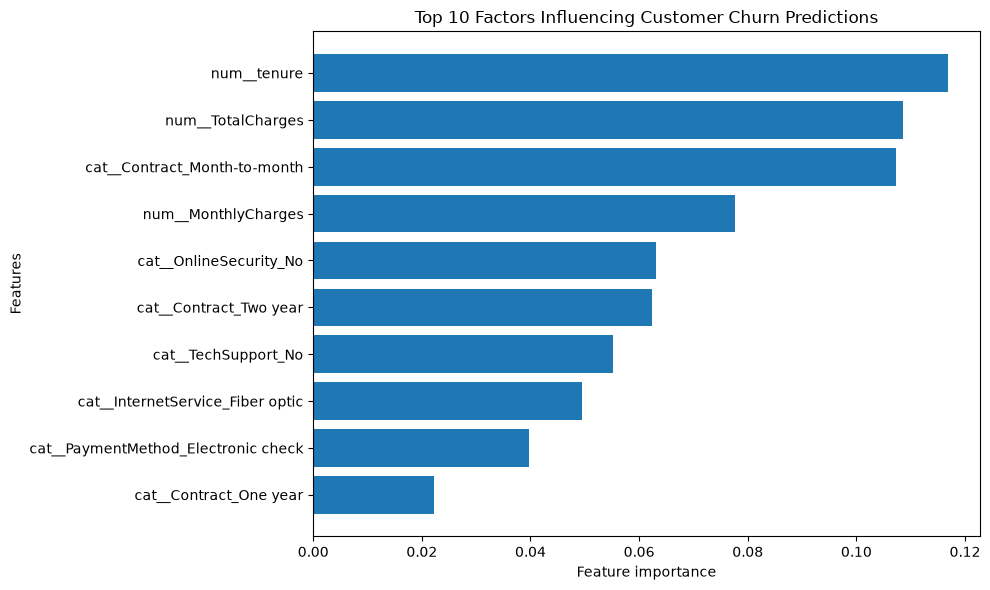

In [22]:
top_10 = importance_df.head(10).sort_values(
    by="Importance", ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Importance"])
plt.title("Top 10 Factors Influencing Customer Churn Predictions")
plt.xlabel("Feature importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### Interpreting Built-in Feature Importance

The feature-importance analysis of the saved Random Forest model identifies customer tenure, TotalCharges, contract type, and MonthlyCharges among the influential predictors. The top features can help identify customer segments for further investigation and targeted retention strategies. Feature importance measures predictive contribution, not causal influence.

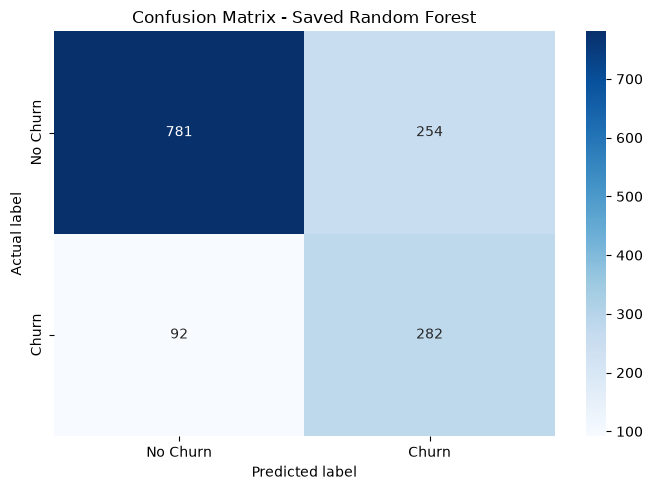

In [23]:
cm = confusion_matrix(y_test, saved_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix - Saved Random Forest")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

## Final Conclusion

The recorded runs show a trade-off between overall performance and churn recall: the 0.35-threshold Logistic Regression snapshot reports higher recall than its default-threshold result, while Random Forest has the stronger F1-score in the recorded comparisons. The saved-model snapshot reports a different accuracy, so these scores should remain identified by evaluation run rather than combined. Before using a model for retention decisions, rerun the notebook from top to bottom and validate the selected model against the project's current data and business costs.

ROC-AUC Score: 0.8386
Average Precision (PR-AUC): 0.6503


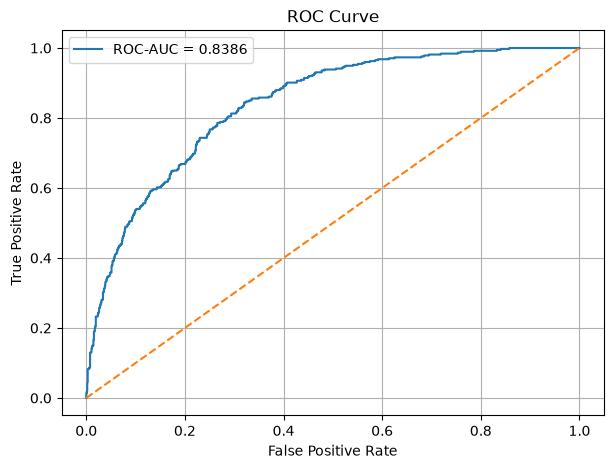

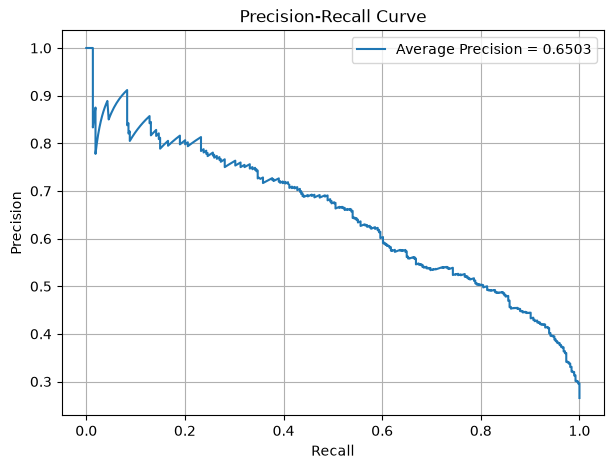

In [24]:
# ROC-AUC and Precision-Recall Evaluation

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Predict churn probabilities using the saved final model
y_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision (PR-AUC): {avg_precision:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Test different classification thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Performance Comparison\n")

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("-" * 30)

Threshold Performance Comparison

Threshold: 0.3
Precision: 0.4411
Recall:    0.9011
F1-score:  0.5923
------------------------------
Threshold: 0.4
Precision: 0.4869
Recall:    0.8449
F1-score:  0.6178
------------------------------
Threshold: 0.5
Precision: 0.5261
Recall:    0.7540
F1-score:  0.6198
------------------------------
Threshold: 0.6
Precision: 0.5612
Recall:    0.6497
F1-score:  0.6022
------------------------------
Threshold: 0.7
Precision: 0.6558
Recall:    0.5401
F1-score:  0.5924
------------------------------


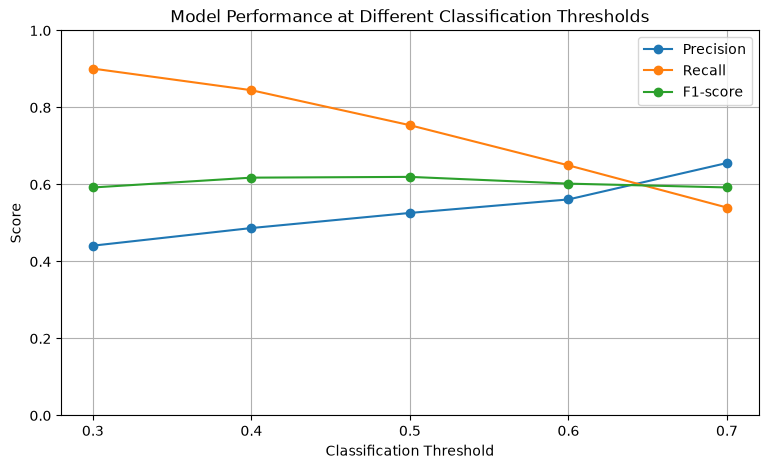

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precisions.append(precision_score(y_test, y_pred_threshold))
    recalls.append(recall_score(y_test, y_pred_threshold))
    f1_scores.append(f1_score(y_test, y_pred_threshold))

plt.figure(figsize=(9, 5))

plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1_scores, marker='o', label='F1-score')

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Model Performance at Different Classification Thresholds')
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()